In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/aaronpole/superstore-clean/superstore_clean.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('/kaggle/input/datasets/aaronpole/superstore-clean/superstore_clean.csv', encoding='latin-1')

df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date']  = pd.to_datetime(df['Ship_Date'],  dayfirst=True)
df['Days_To_Ship'] = (df['Ship_Date'] - df['Order_Date']).dt.days
df['Order_Year']   = df['Order_Date'].dt.year
df['Order_Month']  = df['Order_Date'].dt.month
df['Is_Loss']      = df['Profit'] < 0
df['Discount_Band'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 1], labels=['No Discount', 'Low', 'High'])

print("Ready:", df.shape)

Ready: (9994, 26)


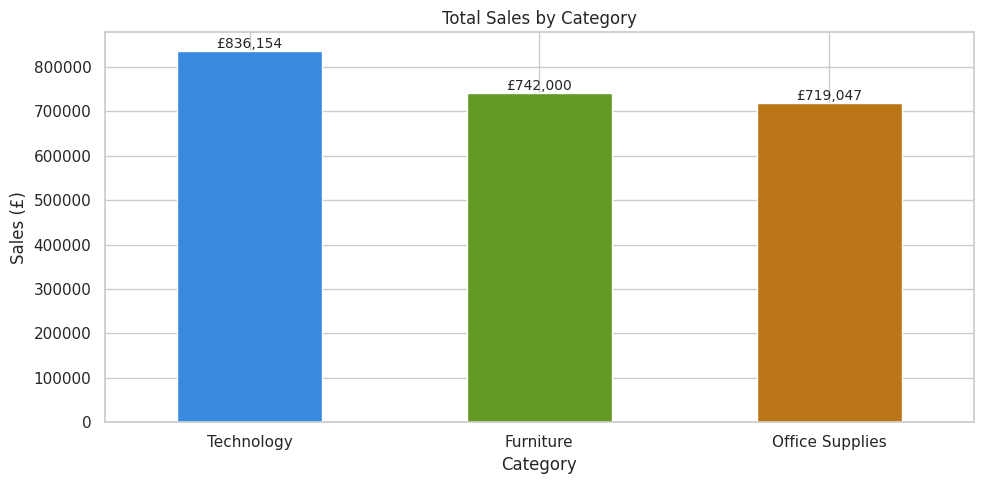

In [4]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

ax = category_sales.plot(kind='bar', color=['#378ADD', '#639922', '#BA7517'])
ax.set_title('Total Sales by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Sales (£)')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.0f}', 
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

*Technology Sector Leads In Sales By Nearly 100k while Furniture and Office come behind closely with a mere difference of 23k.*

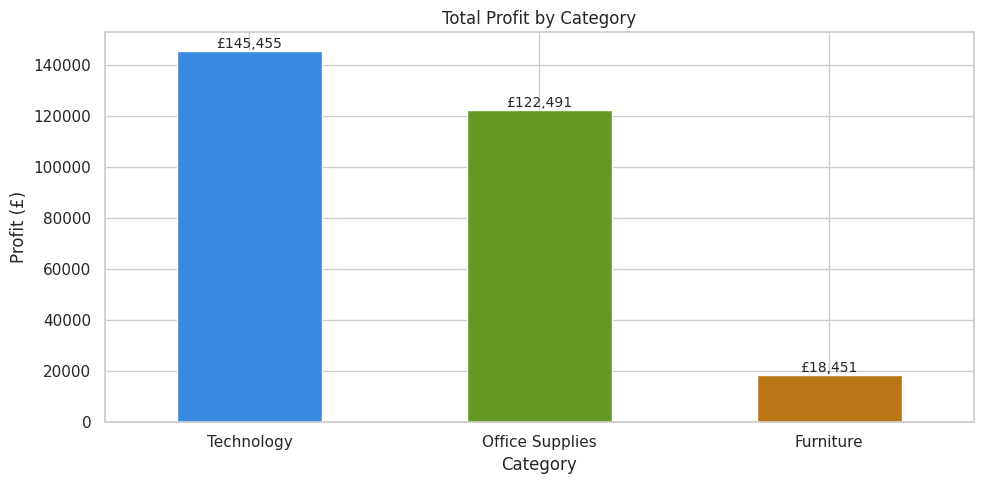

In [5]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

ax = category_profit.plot(kind='bar', color=['#378ADD', '#639922', '#BA7517'])
ax.set_title('Total Profit by Category')
ax.set_xlabel('Category')
ax.set_ylabel('Profit (£)')
ax.tick_params(axis='x', rotation=0)
ax.axhline(0, color='red', linestyle='--', linewidth=1)

for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

*The Technology sector along with high sales brings in high profit while we notice how Furniture despite being 2nd highest in sales brings the least amount of profit indicating it could be the loss making segment*

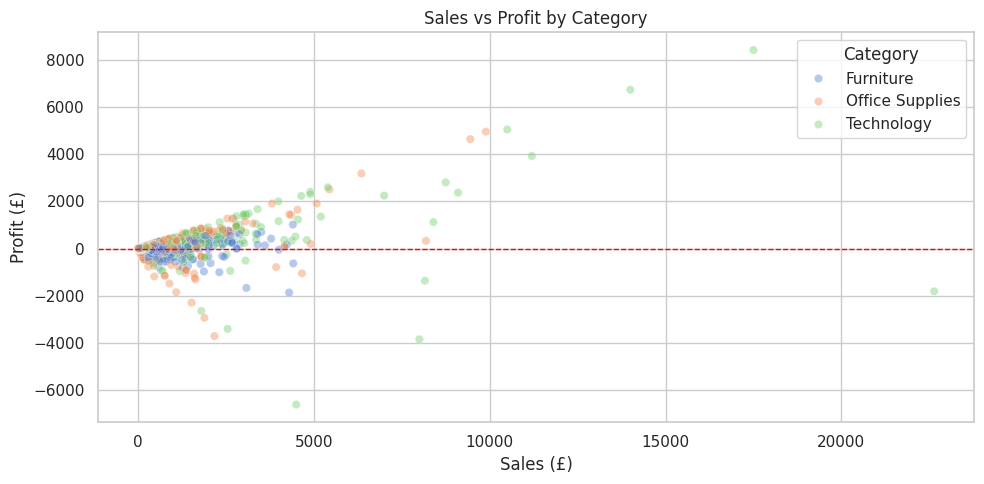

In [6]:
ax = sns.scatterplot(data=df, x='Sales', y='Profit', 
                     hue='Category', alpha=0.4)

ax.set_title('Sales vs Profit by Category')
ax.set_xlabel('Sales (£)')
ax.set_ylabel('Profit (£)')
ax.axhline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

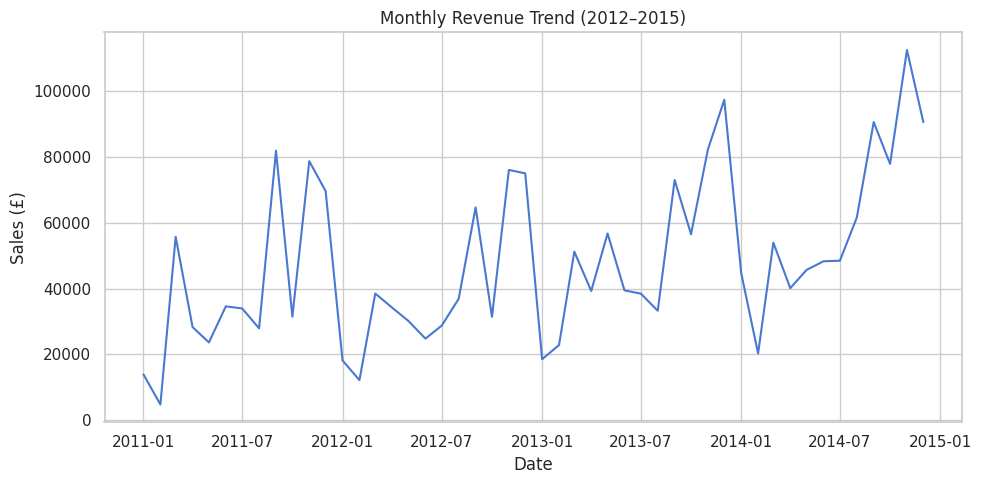

In [10]:
monthly = df.groupby(['Order_Year', 'Order_Month'])['Sales'].sum().reset_index()
monthly['date'] = pd.to_datetime({
    'year':  monthly['Order_Year'],
    'month': monthly['Order_Month'],
    'day':   1
})

ax = sns.lineplot(data=monthly, x='date', y='Sales')
ax.set_title('Monthly Revenue Trend (2012–2015)')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (£)')

plt.tight_layout()
plt.show()

**Seasonality** — there's a sharp spike every year around October-November, then a drop in January. Classic retail pattern — holiday season drives sales.

**Overall growth** — the peaks get higher each year. 2014 peaks are clearly higher than 2011 peaks, showing the business is growing year on year.

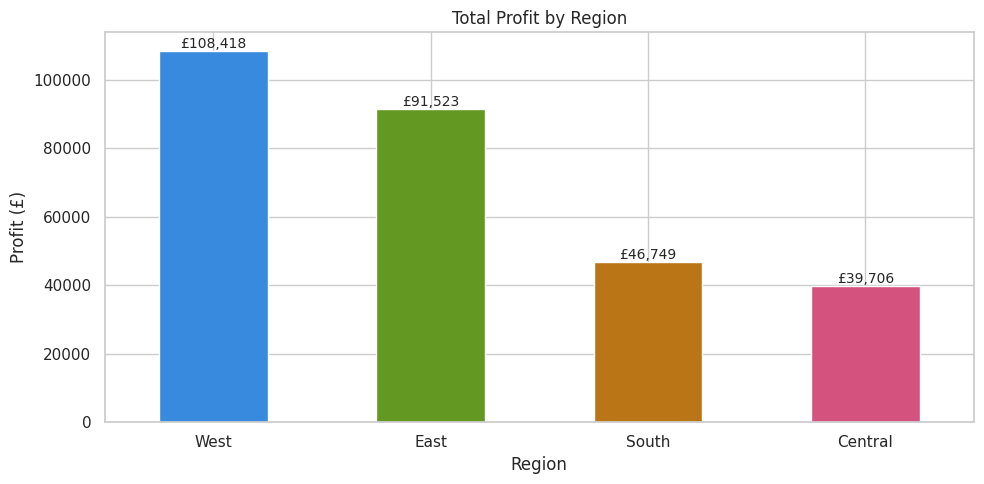

In [11]:
region_profit = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)

ax = region_profit.plot(kind='bar', color=['#378ADD', '#639922', '#BA7517', '#D4537E'])
ax.set_title('Total Profit by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Profit (£)')
ax.tick_params(axis='x', rotation=0)

for p in ax.patches:
    ax.annotate(f'£{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

*Central is the 2nd biggest region by Sales and least profitable region. We see that West gives a profit 2.73x than the Central region.*

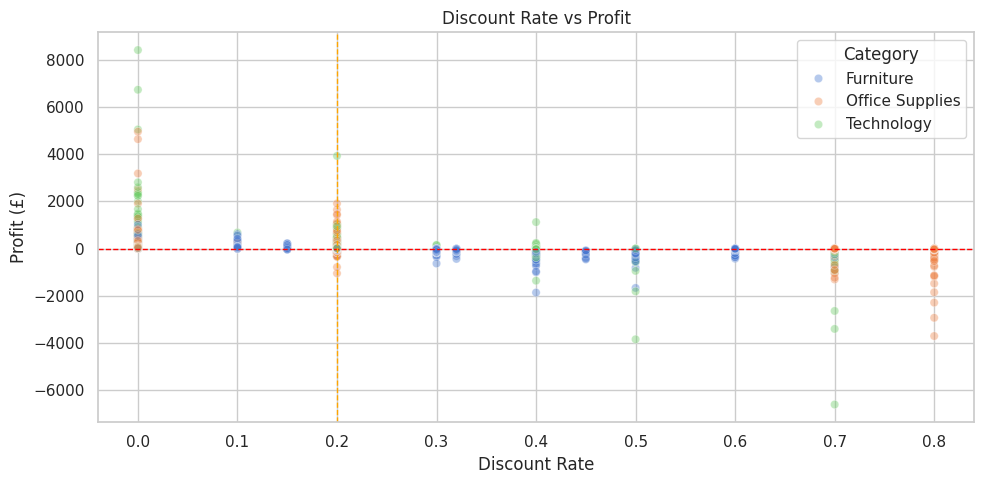

In [12]:
ax = sns.scatterplot(data=df, x='Discount', y='Profit',
                     hue='Category', alpha=0.4)

ax.set_title('Discount Rate vs Profit')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit (£)')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.axvline(0.2, color='orange', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

*Orders with discount above 20% are almost universally loss-making across all categories.
Heavy discounting is the single biggest controllable driver of profit loss in this dataset.*

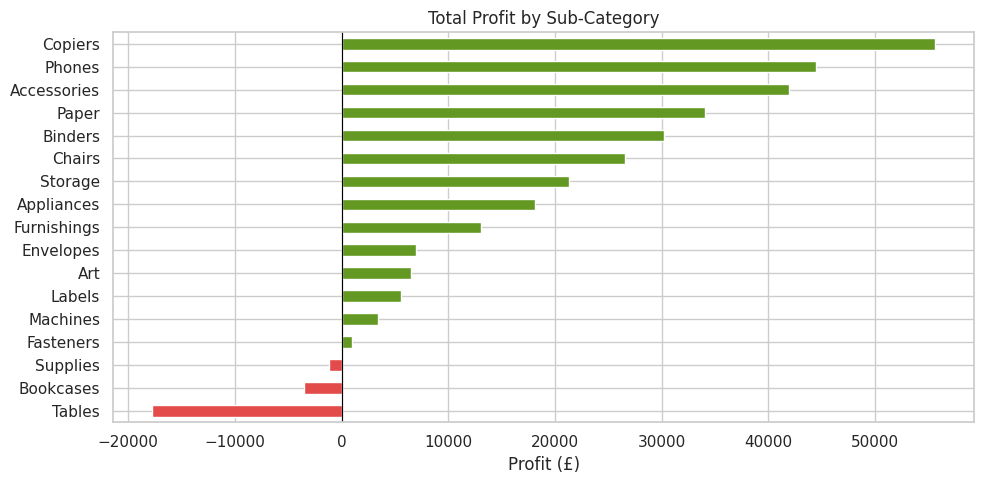

In [14]:
sub_profit = df.groupby('Sub_Category')['Profit'].sum().sort_values()

colors = ['#E24B4A' if x < 0 else '#639922' for x in sub_profit]

ax = sub_profit.plot(kind='barh', color=colors)
ax.set_title('Total Profit by Sub-Category')
ax.set_xlabel('Profit (£)')
ax.set_ylabel('')
ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

*Tables, Bookcases, and Supplies are the only loss-making sub-categories.
Tables drive the majority of Furniture's poor profit performance.*

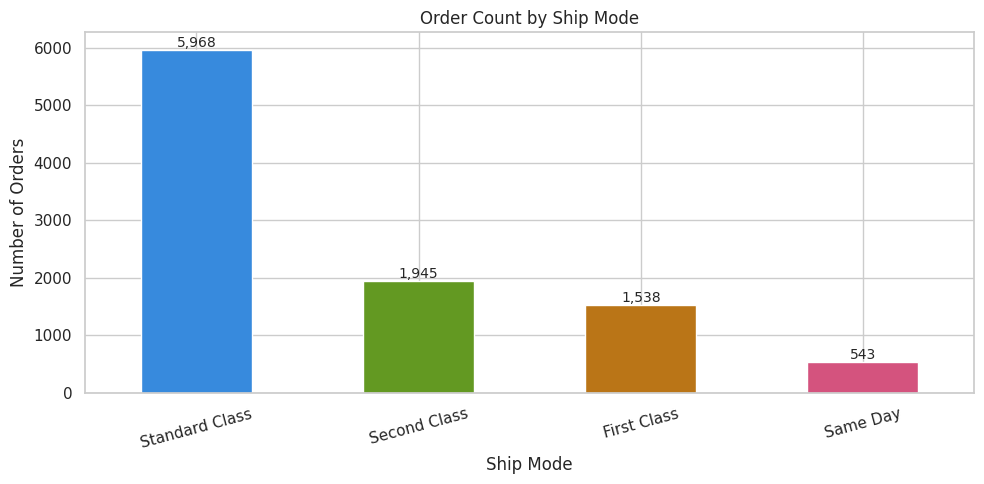

In [16]:
ship_counts = df['Ship_Mode'].value_counts()

ax = ship_counts.plot(kind='bar', color=['#378ADD', '#639922', '#BA7517', '#D4537E'])
ax.set_title('Order Count by Ship Mode')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Number of Orders')
ax.tick_params(axis='x', rotation=15)

for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

*Standard Class accounts for 60% of all shipments. 
Same Day delivery is rarely used, suggesting customers prioritise cost over speed.*

/tmp/ipykernel_58/696952296.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='Ship_Mode', y='Days_To_Ship',


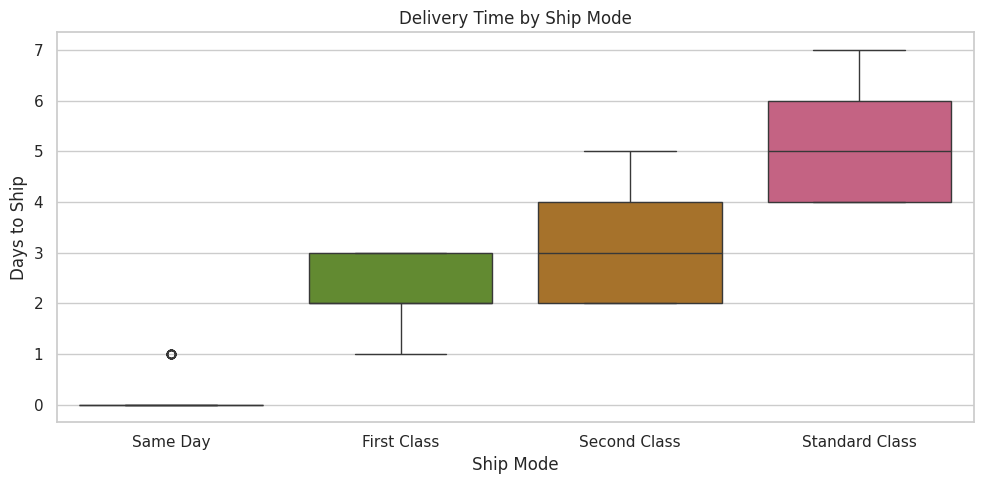

In [17]:
ax = sns.boxplot(data=df, x='Ship_Mode', y='Days_To_Ship',
                 order=['Same Day', 'First Class', 'Second Class', 'Standard Class'],
                 palette=['#378ADD', '#639922', '#BA7517', '#D4537E'])

ax.set_title('Delivery Time by Ship Mode')
ax.set_xlabel('Ship Mode')
ax.set_ylabel('Days to Ship')

plt.tight_layout()
plt.show()

*Same Day ships in 0 days, First Class in 1-2 days, Second Class in 2-4 days, 
Standard Class in 4-7 days. Ship mode labels accurately reflect actual delivery times.*

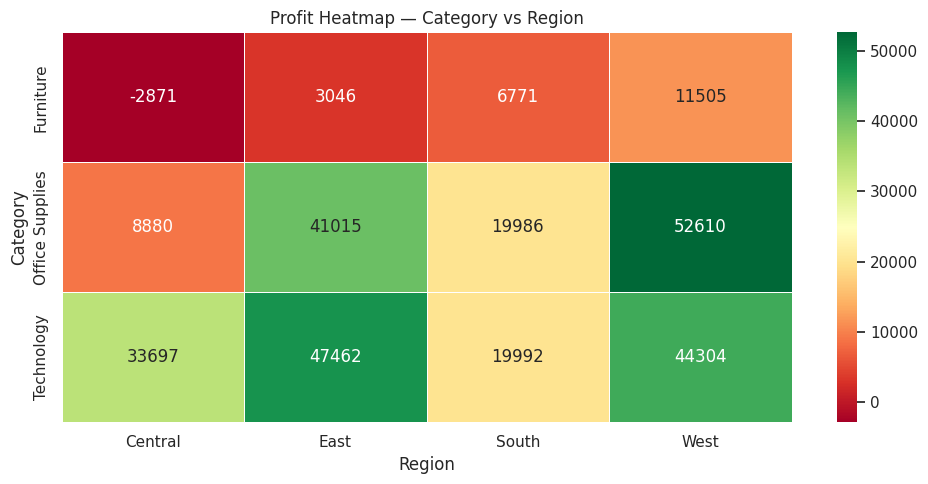

In [18]:
pivot = df.pivot_table(values='Profit', 
                        index='Category', 
                        columns='Region', 
                        aggfunc='sum')

ax = sns.heatmap(pivot, annot=True, fmt='.0f', 
                 cmap='RdYlGn', linewidths=0.5)

ax.set_title('Profit Heatmap — Category vs Region')
ax.set_xlabel('Region')
ax.set_ylabel('Category')

plt.tight_layout()
plt.show()

**Central Furniture is the single worst performing segment — combining the least 
profitable region with the least profitable category. This should be the 
priority area for management intervention.**